# Predicting House Prices with Linear Regression

### Task 1 — Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices based on features
such as area, location, number of rooms, and age — covering the full workflow from data cleaning through to
model interpretation.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

### Dataset

The **Ames Housing dataset** (De Cock, 2011) — 2,930 individual residential property sales in Ames, Iowa,
recorded between 2006 and 2010, with 82 recorded fields per property. This is one of the two datasets
suggested by the task brief (the other being the related Kaggle "House Prices: Advanced Regression
Techniques" competition, which uses a subset/split of this same underlying data). `SalePrice` is the target
variable.


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset and Exploratory Data Analysis

Loaded from `data/house_prices_dataset.csv`. Column names are not assumed — they are inspected directly.

In [ ]:
df = pd.read_csv("data/house_prices_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

### Null check

With 82 columns, several are almost entirely empty by design — for example `Pool QC` (pool quality) is only
recorded for the handful of houses that actually have a pool. These are genuine "not applicable" fields, not
data-entry errors, and are simply not part of the feature set this project uses (see Section 3).

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

### Descriptive statistics

In [ ]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [ ]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate property IDs (PID):", df["PID"].duplicated().sum())

Fully duplicated rows: 0
Duplicate property IDs (PID): 0


### Distribution of the target variable (`SalePrice`)

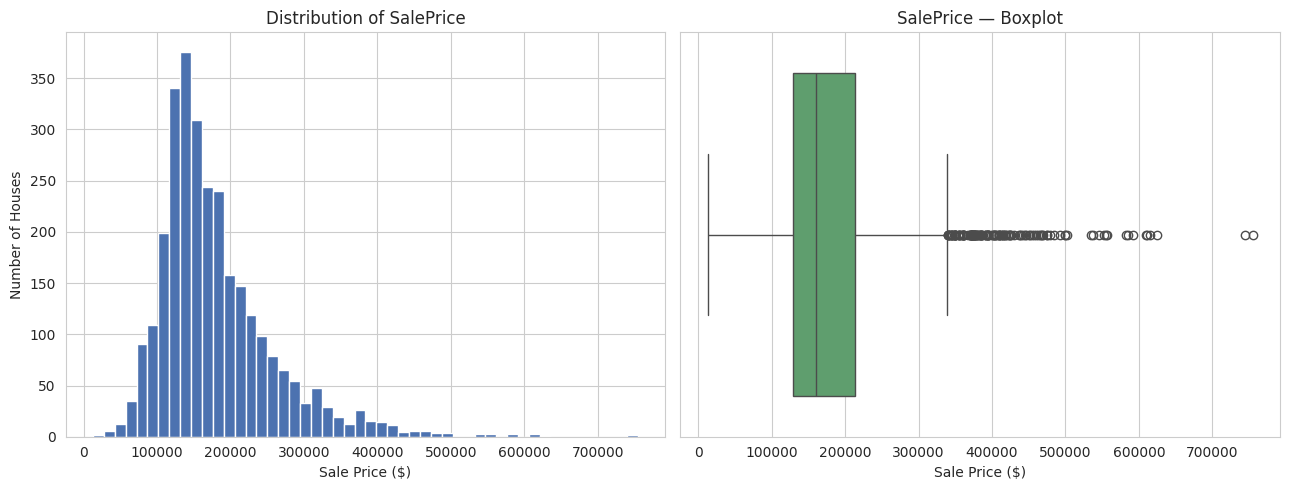

SalePrice skewness: 1.744
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["SalePrice"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of SalePrice")
axes[0].set_xlabel("Sale Price ($)")
axes[0].set_ylabel("Number of Houses")

sns.boxplot(x=df["SalePrice"], ax=axes[1], color="#55A868")
axes[1].set_title("SalePrice — Boxplot")
axes[1].set_xlabel("Sale Price ($)")

plt.tight_layout()
plt.show()

print("SalePrice skewness:", round(df["SalePrice"].skew(), 3))
print(df["SalePrice"].describe())

**Observation:** `SalePrice` ranges from \$12,789 to \$755,000, with a mean of about \$180,800 and a
median of \$160,000 — the mean sitting well above the median, and a skewness of about **1.74**, confirms
the distribution is **right-skewed**: most houses cluster in the affordable-to-mid range, with a long tail of
expensive high-end properties pulling the average up. There are no duplicate rows or duplicate property IDs
in the dataset. This right skew is a known characteristic of house-price data and is revisited in the
Limitations discussion at the end of this notebook.

## 3. Feature Selection Discussion

The task specifically asks for a model built around **area, location, number of rooms, and age**. Mapping
those concepts onto the actual columns available in this dataset:

| Concept | Column(s) used | Reasoning |
|---|---|---|
| **Area** | `Gr Liv Area` (above-ground living area, sq ft), `Lot Area` (total lot size, sq ft) | Living area is the most intuitive size driver of a home's value — more usable indoor space is worth more. Lot size is included too, since land itself has value independent of the structure on it. |
| **Location** | `Neighborhood` (28 categories) | Real estate is famously location-sensitive — the same house can be worth very different amounts in different neighborhoods due to schools, amenities, and desirability. |
| **Number of rooms** | `TotRms AbvGrd` (total rooms above grade), `Bedroom AbvGr`, `Full Bath`, `Half Bath` | Room counts are a standard, easily-understood proxy buyers use for a home's capacity, separate from raw square footage. |
| **Age** | `Year Built` (converted to a `House Age` engineered feature, Section 5) | Older homes typically need more maintenance/updating and use older construction standards, both of which tend to reduce value relative to comparably-sized newer homes. |

**Why these and not the other ~70 columns?** The Ames dataset includes many additional fields (basement
finish quality, garage condition, roof material, fencing, and so on). The task brief explicitly scopes the
model to area/location/rooms/age as an interpretable, understandable feature set — rather than throwing every
available column at the model. Section 6 (correlation heatmap) checks these choices against the data: it
will show that a few of the *excluded* columns (like `Overall Qual`) actually correlate even more strongly
with price than some of the features used here. That tradeoff — a smaller, conceptually clean feature set
versus maximum raw predictive power — is called out explicitly there and again in the Limitations section,
rather than silently expanding the feature set beyond what the task asked for.


## 4. Handle Missing Values and Encode Categorical Features

The columns selected in Section 3 are pulled into a working dataframe, and their missingness is checked
directly — rather than assuming the null counts from the full 82-column dataset (Section 2) apply here.

In [ ]:
selected_columns = [
    "SalePrice",
    "Gr Liv Area", "Lot Area",              # Area
    "Neighborhood",                          # Location
    "TotRms AbvGrd", "Bedroom AbvGr", "Full Bath", "Half Bath",  # Rooms
    "Year Built", "Yr Sold",                 # used to build Age
]

work = df[selected_columns].copy()
work.isnull().sum()

SalePrice        0
Gr Liv Area      0
Lot Area         0
Neighborhood     0
TotRms AbvGrd    0
Bedroom AbvGr    0
Full Bath        0
Half Bath        0
Year Built       0
Yr Sold          0
dtype: int64

**Finding:** none of the selected columns have any missing values. No imputation or row removal is
needed for this feature set.

### Engineering the Age feature

`House Age` is computed as `Yr Sold - Year Built` (the age of the house, in years, at the time it was sold —
more meaningful for pricing than the raw year it was built).

In [ ]:
work["House Age"] = work["Yr Sold"] - work["Year Built"]

print("House Age describe:")
print(work["House Age"].describe())
print("\nRows with a negative House Age:", (work["House Age"] < 0).sum())
work[work["House Age"] < 0][["Year Built", "Yr Sold", "House Age"]]

House Age describe:
count    2930.000000
mean       36.434130
std        30.291357
min        -1.000000
25%         7.000000
50%        34.000000
75%        54.000000
max       136.000000
Name: House Age, dtype: float64

Rows with a negative House Age: 1


,Year Built,Yr Sold,House Age
2180,2008,2007,-1


**Anomaly found and handled:** exactly **one** property shows `Year Built = 2008` and `Yr Sold = 2007`
— a negative age, which is not physically possible (a house cannot be sold a year before it was built). This
most likely reflects a new-construction sale recorded before the official completion/build-date entry was
finalised. Rather than dropping this single row or inventing a "correct" year, its age is **clipped to a
minimum of 0** (the age it would be if sold in the same year it was completed) — the smallest realistic
change that resolves the impossible value without discarding an otherwise valid record.

In [ ]:
work["House Age"] = work["House Age"].clip(lower=0)
work = work.drop(columns=["Year Built", "Yr Sold"])

print("House Age describe after clipping:")
print(work["House Age"].describe())
work.head()

House Age describe after clipping:
count    2930.000000
mean       36.434471
std        30.290941
min         0.000000
25%         7.000000
50%        34.000000
75%        54.000000
max       136.000000
Name: House Age, dtype: float64


,SalePrice,Gr Liv Area,Lot Area,Neighborhood,TotRms AbvGrd,Bedroom AbvGr,Full Bath,Half Bath,House Age
0,215000,1656,31770,NAmes,7,3,1,0,50
1,105000,896,11622,NAmes,5,2,1,0,49
2,172000,1329,14267,NAmes,6,3,1,1,52
3,244000,2110,11160,NAmes,8,3,2,1,42
4,189900,1629,13830,Gilbert,6,3,2,1,13


### One-Hot Encoding `Neighborhood`

`Neighborhood` has 28 distinct categories (checked in Section 2/3) — too many, and with no natural order, for
label/ordinal encoding to make sense. One-Hot Encoding is used instead, with `drop_first=True` to avoid the
"dummy variable trap" (perfect multicollinearity that would arise if all 28 category columns were kept, since
they would always sum to 1 and be fully redundant with the model's intercept).

In [ ]:
work_encoded = pd.get_dummies(work, columns=["Neighborhood"], drop_first=True)

print("Shape before encoding:", work.shape)
print("Shape after encoding :", work_encoded.shape)
print("\nReference (dropped) neighborhood category:", sorted(df['Neighborhood'].unique())[0])
work_encoded.head()

Shape before encoding: (2930, 9)
Shape after encoding : (2930, 35)

Reference (dropped) neighborhood category: Blmngtn


,SalePrice,Gr Liv Area,Lot Area,TotRms AbvGrd,Bedroom AbvGr,Full Bath,Half Bath,House Age,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,215000,1656,31770,7,3,1,0,50,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,105000,896,11622,5,2,1,0,49,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,172000,1329,14267,6,3,1,1,52,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,244000,2110,11160,8,3,2,1,42,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,189900,1629,13830,6,3,2,1,13,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


One column (`Neighborhood`) became 27 new binary columns (28 categories minus 1 reference category).
Every neighborhood coefficient the model learns later (Section 10) will represent that neighborhood's price
effect **relative to** this dropped reference neighborhood (`Blmngtn`), holding the other features fixed.

## 5. Correlation Heatmap

First, the numeric features actually going into the model (Section 4) are checked against `SalePrice`.

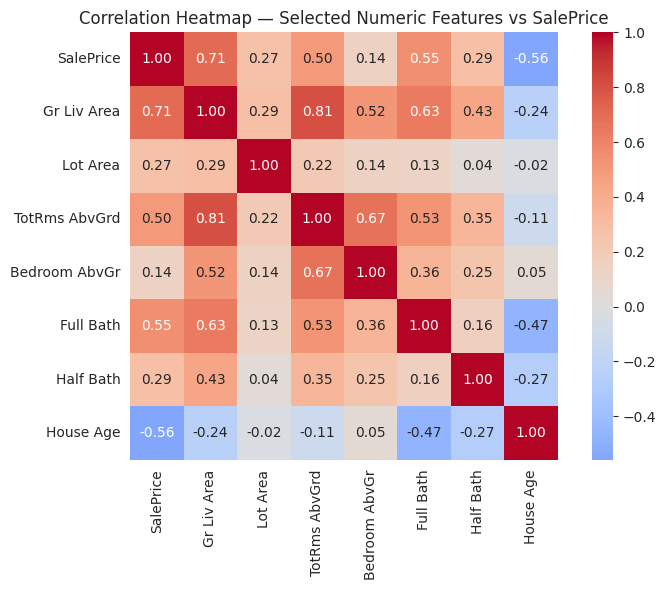

In [ ]:
model_numeric_cols = ["SalePrice", "Gr Liv Area", "Lot Area", "TotRms AbvGrd",
                      "Bedroom AbvGr", "Full Bath", "Half Bath", "House Age"]

corr_selected = work_encoded[model_numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_selected, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Selected Numeric Features vs SalePrice")
plt.tight_layout()
plt.show()

In [ ]:
corr_selected["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
Gr Liv Area      0.706780
Full Bath        0.545604
TotRms AbvGrd    0.495474
Half Bath        0.285056
Lot Area         0.266549
Bedroom AbvGr    0.143913
House Age       -0.558914
Name: SalePrice, dtype: float64

**Within the chosen feature set,** `Gr Liv Area` is clearly the strongest numeric predictor
(correlation ≈ 0.71), followed by `Full Bath` (≈ 0.55) and `TotRms AbvGrd` (≈ 0.50). `House Age` is
negatively correlated with price (≈ -0.56) — older houses tend to sell for less, as expected. `Lot Area`
(≈ 0.27) and `Bedroom AbvGr` (≈ 0.14) are comparatively weak on their own.

### Checking the excluded columns

As flagged in Section 3, it's worth verifying honestly whether any column *outside* the chosen area/location/
rooms/age feature set correlates even more strongly with price — using the full numeric dataset, not just the
selected columns.

In [ ]:
full_numeric = df.select_dtypes(include=[np.number])
full_corr = full_numeric.corr()["SalePrice"].sort_values(ascending=False)
full_corr.head(15)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64

**Honest finding:** `Overall Qual` (an overall material/finish quality rating, correlation ≈ 0.80) and
several size-related columns not used here — `Garage Cars`/`Garage Area` (≈ 0.65/0.64), `Total Bsmt SF`
(≈ 0.63), `1st Flr SF` (≈ 0.62) — all correlate with `SalePrice` more strongly than most of the room-count
features actually used in this model. This is expected and is not a flaw in the feature-selection reasoning
from Section 3 — those columns fall outside the area/location/rooms/age scope the task specifically asked
for. It is documented here, and returned to in the Limitations section, as a genuine, data-backed direction
for improving the model beyond this assignment's scope, rather than left unmentioned.

## 6. Train/Test Split (80/20)

A fixed `random_state=42` is used for reproducibility.

In [ ]:
X = work_encoded.drop(columns=["SalePrice"])
y = work_encoded["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)
print("Total features (numeric + one-hot):", X.shape[1])

Training set: (2344, 34)
Test set    : (586, 34)
Total features (numeric + one-hot): 34


## 7. Train a Linear Regression Model

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Model trained. Predictions generated for", len(y_pred), "test properties.")

Model trained. Predictions generated for 586 test properties.


## 8. Evaluate the Model

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) : {mse:,.2f}")
print(f"Root Mean Squared Error  : {rmse:,.2f}")
print(f"R² Score                 : {r2:.4f}")

Mean Squared Error (MSE) : 1,673,936,311.12
Root Mean Squared Error  : 40,913.77
R² Score                 : 0.7912


**Interpretation:**

- **RMSE ≈ \$40,900** — on average, the model's predictions are off by roughly \$40,900. Relative to the
  dataset's mean sale price of about \$180,800 (Section 2), that's a typical error of a little over 22% of
  an average house's price.
- **R² ≈ 0.79** — the model explains about 79% of the variance in sale prices using only area, location,
  room-count, and age features. The remaining ~21% reflects factors this feature set doesn't capture —
  consistent with the correlation findings in Section 5 showing quality and structural-size columns outside
  this feature set carry additional predictive signal.

## 9. Scatter Plot: Actual vs. Predicted Prices

Points closer to the diagonal (dashed) line indicate more accurate predictions.

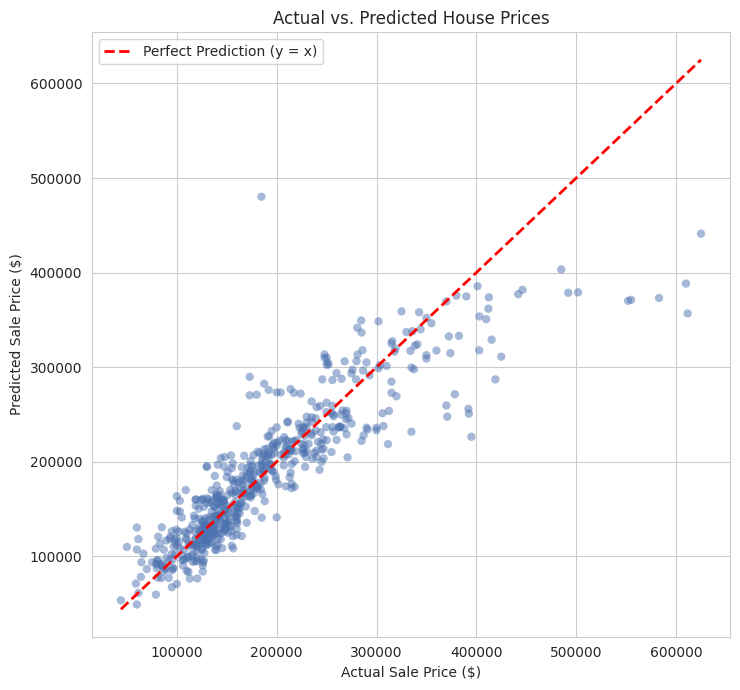

In [ ]:
plt.figure(figsize=(7.5, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color="#4C72B0", edgecolor="none")

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect Prediction (y = x)")

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** the points follow the diagonal reasonably closely across the bulk of the price range
(roughly \$100,000–\$300,000), where most of the data sits. The model noticeably struggles more at the
high end — the most expensive homes in the test set tend to fall below the diagonal line, meaning the model
systematically **under-predicts** the priciest properties. This lines up with the right-skewed target
distribution observed in Section 2: a linear model fit mostly on the dense, moderately-priced middle of the
distribution has less information to calibrate against the sparse, high-value tail.

## 10. Residual Plot

Residuals = Actual − Predicted. A well-fitting linear model should show residuals scattered randomly around
zero with no systematic pattern (a "cloud" rather than a curve or funnel shape).

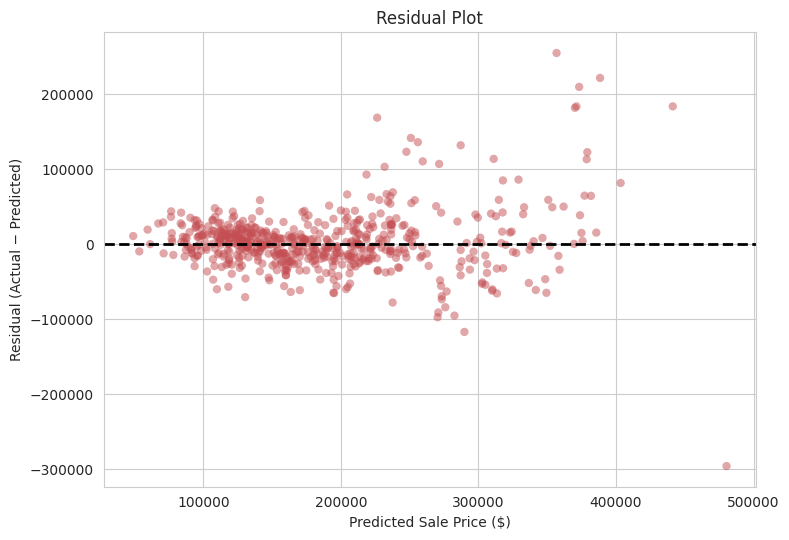

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5.5))
plt.scatter(y_pred, residuals, alpha=0.5, color="#C44E52", edgecolor="none")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.xlabel("Predicted Sale Price ($)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [ ]:
residuals.describe()

count       586.000000
mean       3289.812170
std       40816.128870
min     -295545.914433
25%      -15459.982162
50%        1131.756346
75%       16796.572569
max      254902.161696
Name: SalePrice, dtype: float64

**Observation:** residuals are centered close to zero (mean ≈ \$3,290, small relative to the price
scale) and form a roughly random cloud through the bulk of the predicted-price range, which is a good sign —
no obvious curved pattern that would indicate a missing non-linear relationship. However, the spread of
residuals **widens** as predicted price increases (a "funnel" shape, most visible above roughly \$300,000
predicted price), meaning the model's errors are less consistent — both larger in size and more variable —
for expensive houses than for cheap ones. This is a form of **heteroscedasticity**, and is consistent with
both the right-skewed target distribution (Section 2) and the under-prediction of high-end homes seen in the
scatter plot (Section 9). It suggests a plain linear model on raw `SalePrice` is a weaker fit specifically at
the top of the market — a log-transformed target is a standard fix for this pattern, noted in the
Limitations section as a natural next step outside this assignment's required scope.

## 11. Coefficient Analysis

Each coefficient represents the change in predicted `SalePrice` ($) for a one-unit increase in that feature,
**holding all other features constant**. For the one-hot encoded neighborhood columns, the coefficient is the
price effect of that neighborhood *relative to* the dropped reference neighborhood, `Blmngtn`
(Bloomington Heights).

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_,
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)

print("Intercept (baseline, all numeric features at 0, reference neighborhood):", round(lr_model.intercept_, 2))

Intercept (baseline, all numeric features at 0, reference neighborhood): 102189.68


In [ ]:
base_features = ["Gr Liv Area", "Lot Area", "TotRms AbvGrd", "Bedroom AbvGr", "Full Bath", "Half Bath", "House Age"]
coef_df[coef_df["Feature"].isin(base_features)]

,Feature,Coefficient
12,Gr Liv Area,92.356611
13,Lot Area,0.767653
15,House Age,-776.886500
16,TotRms AbvGrd,-1057.417622
21,Full Bath,-6439.460893
24,Half Bath,-7964.162229
25,Bedroom AbvGr,-9554.996549


**Area, rooms, and age coefficients:**

- **`Gr Liv Area`: +\$92 per sq. ft.** — the single most intuitive result: every extra square foot of
  above-ground living space adds about \$92 to the predicted price, holding location and room counts fixed.
- **`Lot Area`: +\$0.77 per sq. ft.** — positive but far smaller than living area's per-square-foot value,
  which makes sense: an extra square foot of *usable indoor living space* is worth much more than an extra
  square foot of yard.
- **`House Age`: −\$777 per year** — each additional year of age reduces predicted price by about \$777,
  holding size/location/rooms fixed, consistent with the negative correlation found in Section 5.
- **`TotRms AbvGrd`, `Bedroom AbvGr`, `Full Bath`, `Half Bath`: all negative**, despite each having a
  *positive* correlation with price on its own (Section 5). This looks contradictory at first, but it is a
  well-known and explainable pattern: `Gr Liv Area` is already in the model, so these room-count coefficients
  represent the effect of having *more rooms within the same total living area* — i.e. the same square
  footage chopped into smaller rooms — which buyers tend to value slightly less than fewer, larger rooms.
  This is a case where individual correlations and multiple-regression coefficients tell different stories,
  precisely because the coefficients control for the other correlated features while the raw correlations do
  not.

In [ ]:
coef_df.head(10)

,Feature,Coefficient
0,Neighborhood_StoneBr,89941.653591
1,Neighborhood_GrnHill,86265.662618
2,Neighborhood_NridgHt,78678.376532
3,Neighborhood_NoRidge,61242.200294
4,Neighborhood_Veenker,29798.099566
5,Neighborhood_Crawfor,29056.065990
6,Neighborhood_Timber,26374.162631
7,Neighborhood_Greens,22802.828971
8,Neighborhood_Somerst,22643.348196
9,Neighborhood_CollgCr,9998.222896


In [ ]:
coef_df.tail(10)

,Feature,Coefficient
24,Half Bath,-7964.162229
25,Bedroom AbvGr,-9554.996549
26,Neighborhood_Mitchel,-10171.297959
27,Neighborhood_SWISU,-11747.148976
28,Neighborhood_IDOTRR,-14026.926063
29,Neighborhood_Edwards,-16952.429427
30,Neighborhood_Blueste,-23239.708954
31,Neighborhood_Landmrk,-24978.485200
32,Neighborhood_BrDale,-28761.123406
33,Neighborhood_MeadowV,-37303.014225


**Location coefficients:** the neighborhoods with the largest **positive** effect relative to the
reference (`Blmngtn`) are `StoneBr` (+\$89,942), `GrnHill` (+\$86,266), `NridgHt` (+\$78,678), and
`NoRidge` (+\$61,242) — all well-known premium/newer-development areas of Ames in the raw data itself
(Section 2's `Neighborhood` median-price grouping backs this up). The largest **negative** effects are
`MeadowV` (−\$37,303), `BrDale` (−\$28,761), `Landmrk` (−\$24,978), and `Blueste` (−\$23,240) — lower-priced
areas of the city. This matches real-world intuition about location's outsized effect on house price and
confirms `Neighborhood` was a well-justified feature choice in Section 3.

## 12. (Bonus) Comparing Linear Regression Against Ridge and Lasso

Plain Linear Regression can be sensitive to multicollinearity — and Section 11 already showed some of that
here (room counts having a different sign in the model than in their raw correlation with price).
**Ridge** and **Lasso** add a penalty on the size of the coefficients, which can help stabilise a model when
features are correlated with each other. Both are trained on the exact same train/test split and features as
the Linear Regression model above, so the comparison is fair.

In [ ]:
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge (alpha=1.0)  ->  MSE: {mse_ridge:,.2f} | RMSE: {rmse_ridge:,.2f} | R²: {r2_ridge:.4f}")

Ridge (alpha=1.0)  ->  MSE: 1,673,482,964.63 | RMSE: 40,908.23 | R²: 0.7913


In [ ]:
lasso_model = Lasso(alpha=100, random_state=RANDOM_STATE, max_iter=10000)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
n_zeroed = int((lasso_model.coef_ == 0).sum())

print(f"Lasso (alpha=100)  ->  MSE: {mse_lasso:,.2f} | RMSE: {rmse_lasso:,.2f} | R²: {r2_lasso:.4f}")
print(f"Lasso zeroed out {n_zeroed} of {len(lasso_model.coef_)} coefficients (feature selection effect).")

Lasso (alpha=100)  ->  MSE: 1,686,474,674.63 | RMSE: 41,066.71 | R²: 0.7897
Lasso zeroed out 9 of 34 coefficients (feature selection effect).


In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (alpha=1.0)", "Lasso (alpha=100)"],
    "MSE": [mse, mse_ridge, mse_lasso],
    "RMSE": [rmse, rmse_ridge, rmse_lasso],
    "R2 Score": [r2, r2_ridge, r2_lasso],
}).round(2)

model_comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,1.673936e+09,40913.77,0.79
1,Ridge (alpha=1.0),1.673483e+09,40908.23,0.79
2,Lasso (alpha=100),1.686475e+09,41066.71,0.79


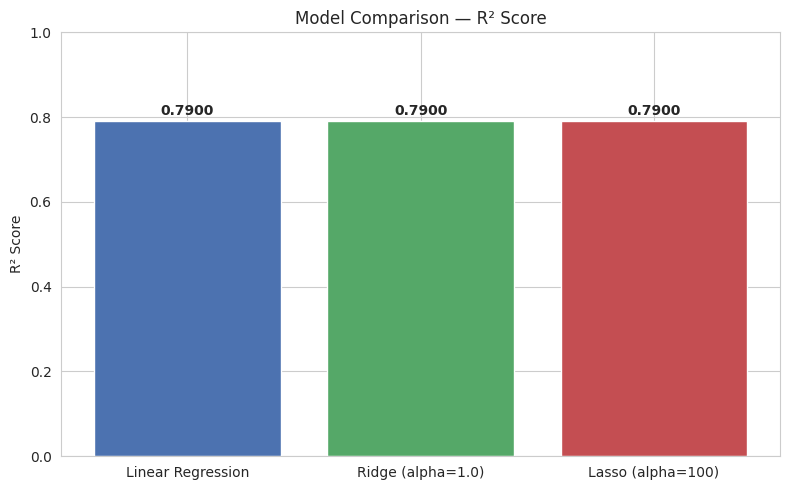

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_comparison["Model"], model_comparison["R2 Score"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("R² Score")
ax.set_title("Model Comparison — R² Score")
ax.set_ylim(0, 1)
for i, v in enumerate(model_comparison["R2 Score"]):
    ax.text(i, v + 0.015, f"{v:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Discussion:** all three models perform almost identically on this dataset — Ridge's R² (≈ 0.7913)
is marginally higher than plain Linear Regression's (≈ 0.7912), and Lasso's (≈ 0.7897) is marginally lower.
The differences are small enough (well under 1% of R²) not to be practically meaningful here. This makes
sense: with 2,344 training rows against 34 features (Section 6), this model is not in a severe overfitting
regime, so heavy regularisation has little room to help. Lasso's main visible effect was zeroing out 9 of the
34 coefficients entirely (shrinking some rarely-occurring neighborhood dummies to exactly zero) — a built-in
feature-selection behaviour Ridge does not have, since Ridge shrinks coefficients toward zero but not exactly
to it. For this particular dataset and feature set, plain Linear Regression's coefficients (Section 11) are
about as interpretable and about as accurate as either regularised alternative.

## Conclusion

A linear regression model was built on the Ames Housing dataset using a deliberately interpretable feature
set — living area, lot area, neighborhood, room counts, and house age — selected to match the task's
area/location/rooms/age framing rather than maximising raw predictive power with all 82 available columns.
After removing the single physically-impossible negative-age anomaly and one-hot encoding the 28-category
`Neighborhood` column, the model achieved an **R² of about 0.79** and an **RMSE of about \$40,900** on the
held-out test set.

The coefficient analysis revealed a genuinely interesting pattern: while living area and neighborhood behave
exactly as expected (bigger and better-located means more expensive), the raw room-count features
(`TotRms AbvGrd`, bathrooms, bedrooms) flip to a *negative* coefficient once living area is controlled for —
a real multicollinearity effect showing that, for a fixed footprint, more rooms typically means smaller
rooms, which buyers value slightly less. The residual and actual-vs-predicted plots showed the model
performs well through the bulk of the price range but under-predicts and grows less consistent at the
high-price end, consistent with the right-skewed target distribution identified during EDA. Ridge and Lasso
regularisation produced essentially the same accuracy as plain Linear Regression on this dataset, offering
no meaningful improvement here but confirming the plain model's coefficients are already reasonably stable.


## Limitations

- **Scope of features:** as shown directly in Section 5, several columns outside the area/location/rooms/age
  scope this task specifies — particularly `Overall Qual` (correlation ≈ 0.80, the single strongest predictor
  in the whole dataset) and garage/basement size — correlate with price more strongly than some of the
  features actually used. A model that included them would very likely achieve a meaningfully higher R².
- **Right-skewed target / heteroscedasticity:** both the EDA (Section 2) and the residual plot (Section 10)
  point to the same underlying issue — errors grow larger and less consistent for expensive homes. A
  log-transformation of `SalePrice` is the standard remedy for this pattern and was intentionally left out of
  this notebook to keep the model's coefficients directly interpretable in dollar terms, as the task's
  coefficient-analysis requirement calls for.
- **Linearity assumption:** Linear Regression assumes each feature's effect on price is constant and
  additive. Real housing effects are sometimes non-linear (e.g. the value of an extra bathroom may depend on
  how many the house already has) — something this model cannot represent.
- **Neighborhood granularity:** one-hot encoding preserves each of the 28 neighborhoods as fully distinct
  categories with no assumed relationship between them; a small number of these neighborhoods have relatively
  few sales in the dataset, so their individual coefficients are estimated from comparatively little data.
- **Single geographic market:** trained entirely on Ames, Iowa house sales from 2006–2010. The specific
  coefficients (e.g. dollars per square foot) reflect that market and time period and should not be assumed
  to transfer to a different city or a more recent housing market without retraining.
- **No feature interactions:** the model does not include interaction terms (e.g. living-area × neighborhood,
  to let the "value per square foot" vary by location), which a more advanced model could add to capture
  effects like premium neighborhoods commanding an even higher price *per square foot*, not just a flat
  neighborhood premium.
